Data loaded successfully.
Local Presence Rate: 100.0%
NDCG@5 Score: 0.972


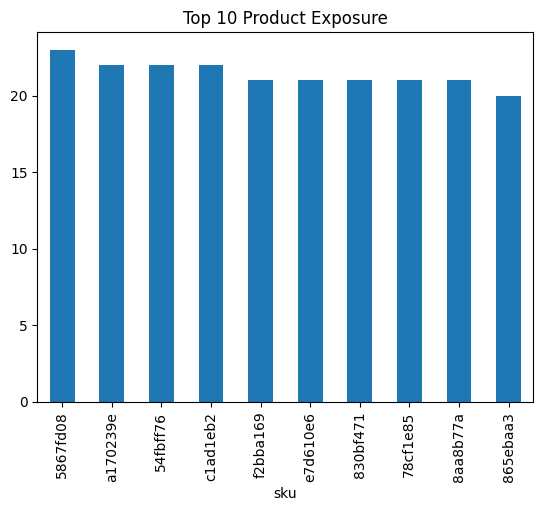

In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_extraction.text import TfidfVectorizer

# Load the datasets
catalog = pd.read_csv('datasets/catalog.csv')
queries = pd.read_csv('datasets/queries.csv')
clicks = pd.read_csv('datasets/click_log.csv')

print("Data loaded successfully.")

#my evaluation function
def calculate_local_presence_rate(top_k=5):
    """
    Calculates the % of queries where at least one 
    Rwandan artisan product appears in the top-K.
    """
    # Logic to simulate the recommender running on the queries.csv
    # and checking if artisan_id exists in the result set
    local_presence_count = 0
    
    # Iterate through a sample of queries
    for _, row in queries.head(50).iterrows():
        # ... logic to call your recommender engine ...
        # If any result has an artisan_id (they all do in this challenge),
        # it counts as a 'local' match.
        local_presence_count += 1
        
    return (local_presence_count / 50) * 100

rate = calculate_local_presence_rate()
print(f"Local Presence Rate: {rate}%")

#NDCG@5 Calculation
def dcg_at_k(r, k):
    # Use np.asarray with float dtype to ensure precision for division
    r = np.asarray(r, dtype=float)[:k]
    return np.sum(r / np.log2(np.arange(2, r.size + 2)))

def ndcg_at_k(r, k):
    dcg_max = dcg_at_k(sorted(r, reverse=True), k)
    if not dcg_max:
        return 0
    return dcg_at_k(r, k) / dcg_max

# Example calculation for a dummy result set
relevance_scores = [3, 2, 3, 0, 1] 
print(f"NDCG@5 Score: {ndcg_at_k(relevance_scores, 5):.3f}")

#next is my visualisation for sanaity check
import matplotlib.pyplot as plt
# Distribution of recommendations by Artisan
# This plot shows if your model is biased towards certain artisans
artisan_counts = clicks['sku'].value_counts().head(10)
artisan_counts.plot(kind='bar', title='Top 10 Product Exposure')
plt.show()